[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/A7_sales_pipeline.ipynb)

> 📎 **Appendix notebook — full-lesson style.** Module 7's seventh appendix (see `README.md`), written like the module's core notebooks: same rhythm, same ✋/🧪/🧠 ladder. It runs on the core course stack (`numpy`, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`) with all data generated inline — 100 % offline.

---
# 📓 Notebook A7 (IA) — Sales: Lead Scoring, Pipeline Truth & the Quarter Forecast

> **Module:** Industry Applications · **Type:** Appendix · **Estimated time:** ~2 h 45 m · **Difficulty:** ⭐⭐ (stretch ⭐⭐⭐)

HelpDeskAI — NB 23's subscription support-bot company — grew up. It now has a 12-rep B2B sales team selling Pro and Enterprise plans, and three artifacts rule its Mondays: the **CRM pipeline** (every open deal carries a rep-entered stage and win probability), the **marketing lead queue** (more inbound leads than the SDRs can call), and the **quarterly forecast** the VP Sales reads to the board. All three run on numbers a model could improve. This notebook improves them.

The antagonist is not a competitor — it is the CRM's own numbers, and it attacks twice. First, rep-entered win probabilities are systematically mis-calibrated, in the specific ways sales folklore predicts (sandbaggers who beat their commit every quarter; happy ears who never met a deal below 60 %). Second — and this is the one that ruins models — **CRM fields get edited after deals close.** The deal size becomes the final negotiated amount, the stage becomes Won/Lost, the dates get tidied. Train on today's export and you are training on hindsight. NB 23's Debug-me built a 0.99-AUC churn model out of a refund flag; today you'll watch the same trap assemble itself out of nothing but ordinary CRM hygiene, because **post-outcome leakage is the default state of every CRM export**, not an exotic accident. NB 26's no-peeking rule returns here wearing a suit.

> 🧠 **Mental model.** A CRM is not a diary; it is a **whiteboard that gets rewritten every time reality changes**. Rep probabilities are *opinions with incentives attached*; stage timestamps are *facts*. Everything in this notebook is one question asked three ways: **what did we actually know on that Monday morning?** Reconstruct the facts as-of (§2), calibrate the opinions against outcomes (§3), and the forecast (§4) and the call list (§5) stop being negotiations and start being arithmetic.

## 🎯 Learning objectives

By the end you can:

1. Rebuild a deal's features **as-of a snapshot date** from a stage-history log, and name the two diseases of naive CRM training data: **post-outcome leakage** and **censoring** of still-open deals.
2. Read a **reliability curve** of rep-entered probabilities, and price a rep's miscalibration in percentage points *and* euros.
3. Beat the reps with a baseline that needs no ML — **stage-level empirical win rates** — then beat that with gradient boosting on as-of features, and say honestly which part of the gain was calibration.
4. Turn win probabilities into a **quarter forecast** with Monte-Carlo error bands, widen the bands for correlated deal outcomes, and backtest the whole thing walk-forward against realized bookings.
5. Rank a lead queue by **expected value** rather than conversion probability, price the difference per SDR-week, and derive the **break-even queue depth** at which calling should stop even with capacity left.
6. Protect next quarter's training data from your own model: the **random holdout slice** (A2's discipline, A4's selection-bias lesson, in sales clothing).

## ✅ Prerequisites

**NB 23** (HelpDeskAI, churn economics, the 0.99-AUC Debug-me — this notebook is the same company two funding rounds later), **NB 17–19** (models, honest evaluation, pipelines & leakage), **NB 26** (the no-peeking rule and time-aware splits). **A2** and **A4** return in §5's closing argument. All data is generated inline; everything runs offline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import roc_auc_score, brier_score_loss

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

SDR_HOURLY = 55.0        # fully loaded SDR cost, EUR / hour
LEAD_HOURS = 1.8         # research + call attempts + follow-up sequence, per worked lead
COST_PER_LEAD = SDR_HOURLY * LEAD_HOURS
GROSS_MARGIN = 0.80      # gross margin on subscription revenue (NB 23's number)
WEEKLY_CAPACITY = 120    # leads the SDR team can actually work, out of ~300 arriving
N_SDRS = 4

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logit(p):
    return np.log(p / (1 - p))

print(f"An SDR hour costs EUR {SDR_HOURLY:.0f}; a worked lead eats ~{LEAD_HOURS} h -> EUR {COST_PER_LEAD:.0f} per lead.")
print(f"The team works {WEEKLY_CAPACITY} of ~300 weekly leads ({N_SDRS} SDRs).")

An SDR hour costs EUR 55; a worked lead eats ~1.8 h -> EUR 99 per lead.
The team works 120 of ~300 weekly leads (4 SDRs).


## 1. The business: one CRM extract, three Monday questions

Every Monday at 09:00, three questions land on three desks:

1. **The SDR team lead:** *~300 new leads came in last week and we can call 120. Which 120?*
2. **The sales manager:** *Which of our open deals are actually going to close? The CRM says one thing, the reps say another.*
3. **The VP Sales:** *What number do I give the board for the quarter?*

Today all three are answered by the same two artifacts: the CRM's rep-entered win probabilities, and the VP's private spreadsheet that re-weights them by stage because she has stopped believing the reps. We are going to rebuild all three answers from data — and because we *simulate* HelpDeskAI's CRM, we get the same superpower A4 used: we know the ground truth we planted (which leads would convert, which deals will win), so we can score our methods against a truth no analyst in production ever sees, and use it **only** for scoring.

We generate ~30 months of history: every lead with its source, company size and industry-fit score; every opportunity with its **full stage history** — timestamps for Lead → Qualified → Demo → Proposal → Negotiation → Won/Lost, and the rep's win probability *as entered at each stage*. Keeping the full history instead of just the current row is the whole point of §2: it is what makes "what did we know on that Monday?" an answerable query.

In [2]:
rng = np.random.default_rng(7)

START = pd.Timestamp("2024-01-01")                 # a Monday; the CRM goes live
N_WEEKS = 130                                      # ~30 months of history
DATA_END = START + pd.Timedelta(weeks=N_WEEKS)     # "this morning": Monday, 29 June 2026

# ---- the lead stream: ~300 a week from three sources ----
n_wk = rng.poisson(300, N_WEEKS)
week = np.repeat(np.arange(N_WEEKS), n_wk)
n = len(week)
source = rng.choice(["outbound", "inbound", "partner"], n, p=[0.38, 0.42, 0.20])
employees = np.round(np.exp(rng.normal(3.3, 1.05, n))).clip(2, 4000)
fit_score = np.clip(rng.normal(50 + 10 * (source == "partner") + 6 * (source == "inbound"), 16, n),
                    5, 100).round()               # marketing's industry-fit score, 0-100
arrival = rng.random(n)                            # order of arrival within the week

# ---- what a deal with this company would look like (plan mix x seats) ----
p_ent = sigmoid(3.0 * (np.log10(employees) - np.log10(170)))
plan = np.where(rng.random(n) < p_ent, "Enterprise", "Pro")
seats = np.clip(4 + rng.binomial(np.minimum(employees, 900).astype(int), 0.12), 4, 60)
price = np.where(plan == "Enterprise", 149.0, 79.0)          # EUR / seat / month
acv_list = seats * price * 12                                 # annual contract value

# ---- planted truth: would this lead convert to an opportunity IF an SDR worked it? ----
# partner referrals convert best, outbound worst; good fit helps; BIG companies convert LESS
z_conv = (-3.25 + 2.10 * (source == "partner") + 1.45 * (source == "inbound")
          + 0.030 * (fit_score - 50) - 0.72 * (np.log10(employees) - 1.45))
p_conv = sigmoid(z_conv)
y_conv = rng.random(n) < p_conv

leads = pd.DataFrame(dict(week=week, source=source, employees=employees,
                          fit_score=fit_score, arrival=arrival, plan=plan, seats=seats,
                          acv_list=acv_list, p_conv=p_conv, y_conv=y_conv))
leads["created"] = START + pd.to_timedelta(leads.week * 7 + np.floor(leads.arrival * 5), unit="D")
# historical policy: first-come-first-served until the week's capacity is gone
leads["worked"] = leads.groupby("week")["arrival"].rank(method="first") <= WEEKLY_CAPACITY

print(f"{len(leads):,} leads over {N_WEEKS} weeks; {int(leads.worked.sum()):,} worked (FCFS), "
      f"{int((leads.worked & leads.y_conv).sum()):,} became opportunities")
print(leads.groupby("source")[["p_conv", "acv_list"]].mean().round(2))
leads[["week", "source", "employees", "fit_score", "plan", "seats", "acv_list"]].head()

39,017 leads over 130 weeks; 15,600 worked (FCFS), 2,466 became opportunities
          p_conv  acv_list
source                    
inbound     0.18  11098.46
outbound    0.04  11240.68
partner     0.31  11198.74


,week,source,employees,fit_score,plan,seats,acv_list
0,0,inbound,3.0,29.0,Pro,4,3792.0
1,0,inbound,47.0,57.0,Pro,7,6636.0
2,0,inbound,23.0,61.0,Enterprise,8,14304.0
3,0,inbound,32.0,63.0,Pro,8,7584.0
4,0,outbound,12.0,46.0,Pro,5,4740.0


In [3]:
# ---- the pipeline: five stages, planted win rates, 12 reps with personalities ----
STAGES = ["Lead", "Qualified", "Demo", "Proposal", "Negotiation"]
TRUE_WIN = np.array([0.08, 0.18, 0.35, 0.55, 0.72])    # planted P(win | deal reaches stage)
ADV_LOGIT = np.array([-0.29, -0.30, 0.04, 0.68, 0.30]) # advance propensities, tuned to hit TRUE_WIN
STAGE_DAYS = np.array([9, 13, 17, 15, 11], float)      # typical days spent in each stage
CRM_DEFAULT = np.array([0.20, 0.35, 0.50, 0.65, 0.80]) # the CRM's suggested win % per stage

REPS = [f"R{i:02d}" for i in range(1, 13)]
# calibration personality as a log-odds offset: >0 = happy ears, <0 = sandbagger
REP_OFFSET = dict(zip(REPS, [+0.85, -0.10, -0.90, +0.15, +0.70, -0.20, -0.70,
                             +0.10, +0.55, -0.05, -0.60, +0.20]))

opps = leads[leads.worked & leads.y_conv].copy().reset_index(drop=True)
m = len(opps)
opps["opp_id"] = np.arange(m)
opps["rep"] = rng.choice(REPS, m)
opps["opp_created"] = opps.created + pd.to_timedelta(rng.integers(1, 8, m), unit="D")
opps["amount"] = np.round(opps.acv_list * rng.uniform(0.85, 1.15, m), -2)   # rep's initial estimate

# planted deal quality: fit up, deal SIZE down, partner up -- and FAST MOVERS win more
speed = np.exp(rng.normal(0, 0.35, m))                  # < 1 = fast mover
size_z = (np.log(opps.acv_list) - np.log(opps.acv_list).mean()) / np.log(opps.acv_list).std()
quality = (0.45 * (opps.fit_score - 50) / 16 - 0.50 * size_z
           + 0.40 * (opps.source == "partner").astype(float) - 0.90 * (speed - 1)
           + rng.normal(0, 0.28, m)).to_numpy()
quality = (quality - quality.mean()) / quality.std()
opps["speed"] = speed

# ---- walk every deal through the stages, logging entry dates and rep probabilities ----
entered = opps.opp_created.to_numpy().astype("datetime64[D]")
alive = np.ones(m, bool)
won = np.zeros(m, bool)
close = np.full(m, np.datetime64("NaT"), dtype="datetime64[D]")
rep_off = opps.rep.map(REP_OFFSET).to_numpy()
parts = []
for s, stage in enumerate(STAGES):
    idx = np.where(alive)[0]
    # the rep enters a win probability on stage entry: CRM default, bent by personality
    rp = np.clip(sigmoid(logit(CRM_DEFAULT[s]) + rep_off[idx] + rng.normal(0, 0.25, len(idx))), 0.05, 0.95)
    rp = np.round(rp * 20) / 20                          # reps think in 5 % steps
    dur = rng.gamma(2.2, STAGE_DAYS[s] / 2.2, len(idx)) * speed[idx]
    p_adv = sigmoid(ADV_LOGIT[s] + 0.80 * quality[idx])
    adv = rng.random(len(idx)) < p_adv
    parts.append(pd.DataFrame({"opp_id": idx, "stage": stage, "stage_idx": s,
                               "entered": entered[idx], "rep_prob": rp}))
    stay = np.where(adv, dur, dur * rng.uniform(1.0, 1.6, len(idx))).round().astype(int)
    end = entered[idx] + stay.astype("timedelta64[D]")
    lose = idx[~adv]
    alive[lose] = False
    close[lose] = end[~adv]
    if s == len(STAGES) - 1:                             # advancing past Negotiation = Won
        alive[idx[adv]] = False
        won[idx[adv]] = True
        close[idx[adv]] = end[adv]
    entered[idx] = end

opps["won"] = won
opps["close_date"] = pd.to_datetime(close)
opps["resolved"] = opps.close_date <= DATA_END           # still-open deals have close dates we can't see yet
stage_log = pd.concat(parts, ignore_index=True)
stage_log["entered"] = pd.to_datetime(stage_log.entered)

print(f"{m:,} opportunities, {int(won.sum())} won ({won.mean():.1%}); "
      f"{opps.resolved.mean():.1%} resolved by {DATA_END.date()}")
print(f"initial deal-size estimates: mean EUR {opps.amount.mean():,.0f}, median EUR {opps.amount.median():,.0f}")

2,466 opportunities, 200 won (8.1%); 97.0% resolved by 2026-06-29
initial deal-size estimates: mean EUR 9,064, median EUR 6,300


P(win | deal reached this stage), resolved deals:
             deals  win_rate
Lead          2391       7.8
Qualified     1073      17.3
Demo           539      34.5
Proposal       328      56.7
Negotiation    257      72.4


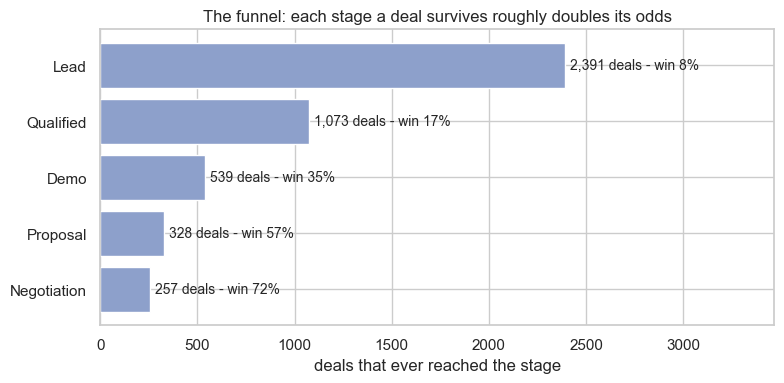

In [4]:
# ---- the funnel, judged on resolved deals only ----
reached = stage_log.merge(opps[["opp_id", "won", "resolved"]], on="opp_id")
reached = reached[reached.resolved & (reached.entered <= DATA_END)]
funnel = reached.groupby("stage_idx").agg(deals=("won", "size"), win_rate=("won", "mean"))
funnel.index = STAGES
print("P(win | deal reached this stage), resolved deals:")
print((funnel.assign(win_rate=(funnel.win_rate * 100).round(1))).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(np.arange(len(STAGES))[::-1], funnel.deals, color="#8da0cb")
for i, (nm, row) in enumerate(funnel.iterrows()):
    ax.text(row.deals + 25, len(STAGES) - 1 - i, f"{row.deals:,.0f} deals - win {row.win_rate:.0%}",
            va="center", fontsize=10)
ax.set_yticks(np.arange(len(STAGES))[::-1], STAGES)
ax.set_xlim(0, funnel.deals.max() * 1.45)
ax.set_xlabel("deals that ever reached the stage")
ax.set_title("The funnel: each stage a deal survives roughly doubles its odds")
plt.tight_layout()

Numbers to keep within reach — they are the skeleton of everything below:

- **~2,500 opportunities**, overall win rate **~8 %** from the moment an SDR opens one. The funnel's conditional win rates land where we planted them: roughly **8 → 17 → 35 → 57 → 72 %**. Compare the CRM's suggested probabilities per stage (20/35/50/65/80): optimistic at *every* stage, and worst exactly where most deals live — early.
- Four more truths are buried in the generator, and every one of them is something a model must *earn* from the data: **partner referrals** convert and win best, **big deals win less often** (`quality` falls with `size_z`), **fast movers win more** (`speed` appears twice: it shortens stage durations *and* raises quality), and each rep bends every probability they enter by a personal, persistent offset.
- One deliberate inconvenience: **~3 % of deals are still open** this morning. They have no label. Remember them; they are §2's second lesson.

Now let's look at the table the analyst would actually export this morning — and at what two years of well-meaning CRM hygiene has done to it.

In [5]:
# ---- the CRM export "as of this morning" -- after two years of post-close editing ----
final_amount = np.where(opps.won,
                        np.round(opps.acv_list * rng.uniform(0.88, 1.08, m), -2),  # won: final negotiated ACV
                        np.where(rng.random(m) < 0.55, 0.0,                        # lost: 55% zeroed by hygiene...
                                 np.round(opps.amount * rng.uniform(0.25, 0.9, m), -2)))  # ...rest "cleaned down"
opps["final_amount"] = final_amount
crm = opps.copy()
crm["amount_now"] = np.where(crm.resolved, crm.final_amount, crm.amount)  # the ONLY amount the export shows
last_reached = stage_log[stage_log.entered <= DATA_END].groupby("opp_id").stage_idx.max()
crm["last_stage_reached"] = crm.opp_id.map(last_reached)
crm["days_in_pipeline"] = (crm.close_date.where(crm.resolved, DATA_END) - crm.opp_created).dt.days
crm["src"] = crm.source.map({"outbound": 0, "inbound": 1, "partner": 2})

# one lost deal, before and after the CRM's memory of it was "tidied":
ex_lost = crm[crm.resolved & ~crm.won & (crm.amount_now == 0)].iloc[0]
print(f"deal {int(ex_lost.opp_id)} (LOST {ex_lost.close_date.date()}):")
print(f"  amount at creation : EUR {ex_lost.amount:>9,.0f}   <- what the rep believed at the time")
print(f"  amount in export   : EUR {ex_lost.amount_now:>9,.0f}   <- zeroed after the loss")
print(f"  days_in_pipeline   : {int(ex_lost.days_in_pipeline)} days      <- computed FROM THE CLOSE DATE")
ex_won = crm[crm.won].iloc[0]
print(f"deal {int(ex_won.opp_id)} (WON {ex_won.close_date.date()}):")
print(f"  amount at creation : EUR {ex_won.amount:>9,.0f}")
print(f"  amount in export   : EUR {ex_won.amount_now:>9,.0f}   <- replaced by the final negotiated ACV")

deal 1 (LOST 2024-02-11):
  amount at creation : EUR     4,300   <- what the rep believed at the time
  amount in export   : EUR         0   <- zeroed after the loss
  days_in_pipeline   : 36 days      <- computed FROM THE CLOSE DATE
deal 14 (WON 2024-01-30):
  amount at creation : EUR     5,800
  amount in export   : EUR     5,600   <- replaced by the final negotiated ACV


## 2. The snapshot discipline — reconstructing what you knew, when

Nobody at HelpDeskAI falsified anything. Reps updated the amount when the contract was signed (of course), ops zeroed lost deals so the pipeline report stopped counting them (sensible), and `days_in_pipeline` is computed from the close date because that is when the deal *ended* (true). Every edit is defensible. Their sum is a table where **the columns quietly contain the outcome**.

Now imagine the Monday request that starts every sales-analytics project: *"build us a model that predicts which open deals will close."* The obvious move — NB 17 reflexes — is to take the export, keep the resolved deals, and fit a classifier on the deal fields. We will even be virtuous and split **by time** (train on deals created before July 2025, test on later ones), exactly as NB 26 taught. The leak is not in the split. It is in the columns.

### 🔮 Predict the output

The features: `amount_now`, `last_stage_reached`, `days_in_pipeline`, `fit_score`, `employees`, `seats`, `src`. The model: the usual `HistGradientBoostingClassifier`. The split: temporal, like good citizens.

Before you run the next cell: **(a)** what test AUC do you expect — ~0.75, ~0.85, or ≥ 0.97? **(b)** Which *single* column is the worst offender, and why? (Hint: for a won deal, what is `last_stage_reached` — always?)

In [6]:
resolved = crm[crm.resolved]
LEAKY = ["amount_now", "last_stage_reached", "days_in_pipeline", "fit_score", "employees", "seats", "src"]
tr_c = resolved[resolved.opp_created < "2025-07-01"]
te_c = resolved[resolved.opp_created >= "2025-07-01"]

contaminated = HistGradientBoostingClassifier(random_state=0).fit(tr_c[LEAKY], tr_c.won)
auc_dirty = roc_auc_score(te_c.won, contaminated.predict_proba(te_c[LEAKY])[:, 1])
print(f"AUC on the current CRM export (temporal test): {auc_dirty:.3f}   <- 'ship it'?? 🚩")

for f in ["amount_now", "last_stage_reached", "days_in_pipeline"]:
    m1 = HistGradientBoostingClassifier(random_state=0).fit(tr_c[[f]], tr_c.won)
    a1 = roc_auc_score(te_c.won, m1.predict_proba(te_c[[f]])[:, 1])
    print(f"  AUC using ONLY {f:20s}: {a1:.3f}")

AUC on the current CRM export (temporal test): 1.000   <- 'ship it'?? 🚩


  AUC using ONLY amount_now          : 0.896
  AUC using ONLY last_stage_reached  : 0.990


  AUC using ONLY days_in_pipeline    : 0.873


**AUC 1.000.** Not 0.99 — a clean, perfect 1.000, from three mundane maintenance habits. `last_stage_reached` alone scores 0.990, because every won deal — by definition — reached Negotiation, while most lost deals died at Lead or Qualified. `amount_now` alone scores 0.896: 55 % of lost deals have amount 0, so the model reads "has money attached" as "won". `days_in_pipeline` (0.873) encodes the close date. The model isn't predicting; it's *reading the answer sheet backwards*. This is NB 23's refund flag, industrialized: not one leaky column added by one careless colleague, but a whole table drifting into hindsight because hindsight is what a CRM is *for*.

Apply NB 26's test — *"would this value exist in the database at scoring time?"* — and the fix names itself. Two lessons, both load-bearing:

1. **Post-outcome leakage.** Train only on what the table said **as-of a date before the outcome**. Our stage log makes that reconstructable: stage at the snapshot, days in that stage, days since creation, the rep's probability *as entered by then*, the *initial* amount estimate — and a velocity feature (stages advanced per 30 days open) for the fast-mover signal.
2. **Censoring.** A snapshot's open deals split into resolved-by-now (usable labels) and **still open (no label yet)**. You can only train on cohorts old enough to have resolved — the same reason NB 26 validated forecasts strictly on time, and a first taste of the survival-analysis view (Stretch B makes it explicit).

We take **biweekly Monday snapshots** through the history, rebuild every open deal's features as-of each snapshot, and train only where the outcome was known by our chosen "forecast day" — 1 January 2026, so we have honest post-period deals to test on.

In [7]:
o_ix = opps.set_index("opp_id")

def snapshot_panel(snap):
    '''The pipeline exactly as it looked on the morning of `snap` -- rebuilt from the stage log.'''
    snap = pd.Timestamp(snap)
    log = stage_log[stage_log.entered <= snap]                        # only events that had HAPPENED
    cur = log.sort_values("entered").groupby("opp_id").tail(1).set_index("opp_id")
    open_ids = cur.index[o_ix.loc[cur.index, "close_date"] > snap]    # not yet resolved that morning
    p = o_ix.loc[open_ids, ["source", "employees", "fit_score", "seats", "plan", "amount",
                            "rep", "opp_created", "close_date", "won", "acv_list", "final_amount"]].copy()
    p["snapshot"] = snap
    p["stage_idx"] = cur.loc[open_ids, "stage_idx"]
    p["stage"] = cur.loc[open_ids, "stage"]
    p["rep_prob"] = cur.loc[open_ids, "rep_prob"]                     # as entered BY THEN
    p["days_in_stage"] = (snap - cur.loc[open_ids, "entered"]).dt.days
    p["days_open"] = (snap - p.opp_created).dt.days
    p["velocity"] = p.stage_idx / p.days_open.clip(lower=1) * 30      # stages advanced per 30 days
    p["src"] = p.source.map({"outbound": 0, "inbound": 1, "partner": 2})
    p["log_amount"] = np.log10(p.amount)
    p["log_emp"] = np.log10(p.employees)
    return p.reset_index()

FEATS = ["stage_idx", "days_in_stage", "days_open", "velocity", "rep_prob",
         "fit_score", "log_emp", "log_amount", "src"]

ALL_SNAPS = pd.date_range("2024-04-01", "2026-06-01", freq="2W-MON")   # biweekly Mondays
PANELS = {s: snapshot_panel(s) for s in ALL_SNAPS}

def training_panel(T):
    '''Everything knowable on morning T: snapshots safely before T, outcomes resolved by T.'''
    T = pd.Timestamp(T)
    ptr = pd.concat([PANELS[s] for s in ALL_SNAPS if s < T - pd.Timedelta(days=13)])
    return ptr[ptr.close_date <= T]        # deals still open on T are CENSORED -> excluded

T0 = pd.Timestamp("2026-01-01")            # the "forecast day" we rewind to for honest evaluation
ptr = training_panel(T0)
raw_rows = sum(len(PANELS[s]) for s in ALL_SNAPS if s < T0 - pd.Timedelta(days=13))
pte = pd.concat([PANELS[s] for s in ALL_SNAPS if T0 <= s <= pd.Timestamp("2026-03-01")])
pte = pte[pte.close_date <= DATA_END]      # for EVALUATION we need the outcome to exist by now

honest = HistGradientBoostingClassifier(random_state=0, learning_rate=0.05, max_leaf_nodes=7,
                                        min_samples_leaf=60, l2_regularization=1.0, max_iter=200)
honest.fit(ptr[FEATS], ptr.won)
auc_honest = roc_auc_score(pte.won, honest.predict_proba(pte[FEATS])[:, 1])
print(f"training snapshot-rows before the censoring filter: {raw_rows:,}; usable: {len(ptr):,}")
print(f"test rows (open on {T0.date()}+, resolved by {DATA_END.date()}): {len(pte)}; "
      f"base win rate {pte.won.mean():.3f}")
print(f"\nhonest as-of AUC: {auc_honest:.3f}   (same model family; the export scored {auc_dirty:.3f})")

# one deal to do by hand in the checkpoint below:
snap0 = pte.snapshot.min()
ex_id = int(pte[(pte.snapshot == snap0) & (pte.stage_idx >= 2)]
            .sort_values(["stage_idx", "days_open"]).opp_id.iloc[-1])
ex_hist = stage_log[(stage_log.opp_id == ex_id) & (stage_log.entered <= snap0)]
print(f"\ndeal {ex_id} -- stage history known by {snap0.date()}:")
print(ex_hist[["stage", "entered", "rep_prob"]].to_string(index=False))
print("\nits as-of feature row that morning:")
print(pte.loc[(pte.opp_id == ex_id) & (pte.snapshot == snap0),
              ["stage", "days_in_stage", "days_open", "velocity", "rep_prob", "amount"]]
      .round(2).to_string(index=False))

training snapshot-rows before the censoring filter: 3,273; usable: 3,207
test rows (open on 2026-01-01+, resolved by 2026-06-29): 291; base win rate 0.165

honest as-of AUC: 0.853   (same model family; the export scored 1.000)

deal 1738 -- stage history known by 2026-01-05:
      stage    entered  rep_prob
       Lead 2025-10-13      0.30
  Qualified 2025-10-18      0.40
       Demo 2025-11-09      0.55
   Proposal 2025-12-09      0.65
Negotiation 2025-12-26      0.85

its as-of feature row that morning:
      stage  days_in_stage  days_open  velocity  rep_prob  amount
Negotiation             10         84      1.43      0.85  4300.0


From **1.000 to 0.853** — that drop is not the model getting worse, it is the *question* getting real. (The two test sets differ — resolved deals vs snapshot rows — but the message survives any reasonable pairing.) 0.85 on genuinely-open deals is strong: stage alone carries a lot, and the as-of features add the fast-mover and fit signals on top. The censoring filter cost only 66 of 3,273 training rows here — cheap, because HelpDeskAI's deals resolve within a quarter or two — but notice *where* it bites: always the freshest snapshots, exactly the ones whose pipeline mix most resembles tomorrow's. Slow-moving businesses (enterprise-only, 18-month cycles) pay this tax in years, which is why they graduate to survival models instead of throwing the open deals away.

> ⚠️ **The rule, portable to any CRM:** never train on the current table. Train on **reconstructed snapshots**, and let a deal appear once per snapshot it was open in — that is exactly the population you will score in production: *open deals, on a Monday, mid-story.*

---

### ✋ Quick exercise (~2 min) — one deal, reconstructed by hand

Use the stage history printed above (its first `entered` date is the day the opportunity was created). For the snapshot morning `snap0`: **(a)** which stage was the deal in, and how many days had it been sitting there? **(b)** how many days had it been open in total? **(c)** `velocity` = stages advanced per 30 days open — compute it. Check all three against the printed feature row.

In [8]:
# ✍️ Your turn 👇
# snap0 and ex_hist are already defined above.
# days_in_stage = snap0 - (entered date of the LAST stage row)
# days_open     = snap0 - (entered date of the FIRST stage row)
# velocity      = stage_idx_now / days_open * 30

<details>
<summary>✅ <b>Solution</b></summary>

```python
first = ex_hist.sort_values("entered").iloc[0]
last = ex_hist.sort_values("entered").iloc[-1]
d_stage = (snap0 - last.entered).days
d_open = (snap0 - first.entered).days
velo = last.stage_idx / max(d_open, 1) * 30
row = pte.loc[(pte.opp_id == ex_id) & (pte.snapshot == snap0)].iloc[0]
print(f"stage {last.stage}: {d_stage} days in stage, {d_open} days open, velocity {velo:.2f}")
print(f"panel row says:    {row.days_in_stage} / {row.days_open} / {row.velocity:.2f}  -> "
      f"{'match ✅' if (d_stage, d_open) == (row.days_in_stage, row.days_open) else 'mismatch ❌'}")
```

The arithmetic is trivial — that is the point. "As-of features" sounds like infrastructure, but it is three subtractions against a timestamp log. What makes it *feel* hard in real projects is that the log usually has to be requested specially (CRMs call it "field history" or "audit trail") while the contaminated current table is one click away. The one-click table costs you an honest model; ask for the log.
</details>

## 3. Are the reps' numbers any good? Calibration before modeling

Before reaching for a model, audit the probabilities the company already pays for: every stage entry, some rep typed a win probability into the CRM. That is thousands of forecasts with known outcomes — a **reliability curve** waiting to be drawn (NB 18 drew one for a model; drawing one for *people* is the same code and considerably more political).

Method note: each observation below is a *stage entry* of a resolved deal — "the rep said 60 % at some point; did the deal eventually close?" We group the entered probabilities into 5 %-bins and compare each bin's claim with its reality.

rep said -> reality (resolved deals):
            n  win_rate
rep_prob               
0.05       51      11.8
0.10      425       8.2
0.15      499       8.0
0.20      595       9.9
0.25      517      11.6
0.30      422      13.3
0.35      414      13.8
0.40      339      20.4
0.45      230      23.5
0.50      179      29.6
0.55      184      32.1
0.60      162      43.8
0.65      138      40.6
0.70      120      49.2
0.75       96      56.2
0.80       81      55.6
0.85       80      71.2
0.90       53      71.7
0.95        3      66.7


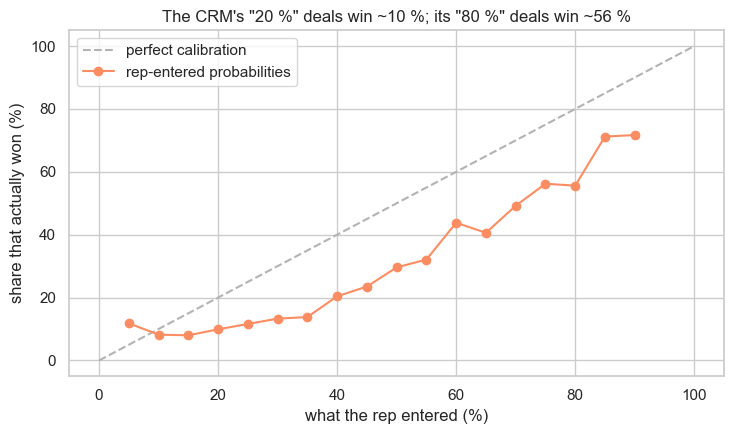

In [9]:
snap_obs = stage_log.merge(opps[["opp_id", "won", "resolved", "rep"]], on="opp_id")
snap_obs = snap_obs[snap_obs.resolved]                       # judge only finished stories
bins = (snap_obs.rep_prob * 20).round() / 20
reliability = snap_obs.groupby(bins).agg(n=("won", "size"), win_rate=("won", "mean"))
reliability["win_rate"] = (reliability.win_rate * 100).round(1)
print("rep said -> reality (resolved deals):")
print(reliability.to_string())

fig, ax = plt.subplots(figsize=(7.5, 4.5))
big = reliability[reliability.n >= 30]
ax.plot([0, 100], [0, 100], "--", color="#b3b3b3", label="perfect calibration")
ax.plot(big.index * 100, big.win_rate, "-o", color="#fc8d62", label="rep-entered probabilities")
ax.set_xlabel("what the rep entered (%)")
ax.set_ylabel("share that actually won (%)")
ax.set_title('The CRM\'s "20 %" deals win ~10 %; its "80 %" deals win ~56 %')
ax.legend()
plt.tight_layout()

The curve sags below the diagonal along its whole length — the pipeline as a *system* is optimistic. Deals carrying a **20 %** label win **9.9 %**; deals carrying **80 %** win **55.6 %**. Two forces produce exactly this shape, and both were planted: the CRM's stage defaults are inflated relative to the true stage win rates (20 vs 8 at Lead, 80 vs 72 at Negotiation), and rep personalities *mix stages within a probability bin* — an optimist's Proposal deal (true ≈ 55 %) wears the same "80 %" as a neutral rep's Negotiation deal (true ≈ 72 %), dragging the bin's reality down.

The per-rep version is where the personas surface. A word before printing it: this table is a **coaching instrument, not a leaderboard**. Publish it as a ranking and you will teach twelve people to game a number (§6 has more to say about that). Read it in aggregate first; use rep-level rows in one-on-ones.

In [10]:
per_rep = snap_obs.groupby("rep").agg(n=("won", "size"), stated=("rep_prob", "mean"),
                                      realized=("won", "mean"))
per_rep["gap_pp"] = ((per_rep.realized - per_rep.stated) * 100).round(1)
print("per-rep calibration (gap = realized - stated, in pp):")
print(per_rep.round(3).sort_values("gap_pp").to_string())

# ---- the fix that needs no ML: stage-level empirical win rates (from the training panel) ----
stage_rates = ptr.groupby("stage_idx").won.mean()
print("\nP(win | open at a snapshot, stage), training panel:",
      (stage_rates * 100).round(1).to_dict())

# ---- three probability sources, one honest test set (open deals on/after the forecast day) ----
y_te = pte.won.to_numpy()
p_model = honest.predict_proba(pte[FEATS])[:, 1]
candidates = {"rep-entered probs": pte.rep_prob.to_numpy(),
              "stage-rate baseline": pte.stage_idx.map(stage_rates).to_numpy(),
              "model (as-of feats)": p_model}
print(f"\n{'probability source':<22} {'AUC':>6} {'Brier':>8}   mean p (base {y_te.mean():.3f})")
for nm, p in candidates.items():
    print(f"{nm:<22} {roc_auc_score(y_te, p):>6.3f} {brier_score_loss(y_te, p):>8.4f}   {p.mean():.3f}")

per-rep calibration (gap = realized - stated, in pp):
       n  stated  realized  gap_pp
rep                               
R01  377   0.512     0.172   -33.9
R05  399   0.495     0.238   -25.7
R09  442   0.454     0.204   -25.0
R04  371   0.364     0.189   -17.5
R12  387   0.378     0.207   -17.1
R06  374   0.288     0.120   -16.8
R10  344   0.319     0.160   -15.9
R08  433   0.371     0.231   -14.0
R02  318   0.303     0.189   -11.5
R03  384   0.191     0.195     0.4
R07  374   0.222     0.241     1.9
R11  385   0.240     0.273     3.3

P(win | open at a snapshot, stage), training panel: {0: 6.9, 1: 13.9, 2: 28.8, 3: 45.3, 4: 60.9}

probability source        AUC    Brier   mean p (base 0.165)
rep-entered probs       0.720   0.1751   0.380
stage-rate baseline     0.782   0.1107   0.178
model (as-of feats)     0.853   0.1075   0.154


Three readings, in ascending order of embarrassment for the CRM:

1. **The reps rank surprisingly well** (AUC 0.720) — because a rep's number is mostly *the stage in disguise*, and stage is genuinely informative. Their problem is the **level**: mean stated 0.380 against a base rate of 0.165, Brier 0.175. If you rolled these numbers into money you'd be off by a factor of ~2.3 before starting.
2. **The dumb baseline embarrasses them.** Counting historical win rates per stage — a `groupby` — matches the reps' ranking (AUC 0.782 vs 0.720) and fixes the level almost completely (Brier 0.111, mean 0.178). One aside worth a sentence: these snapshot-conditioned rates (6.9/13.9/28.8/45.3/60.9 %) sit *below* the at-entry funnel rates from §1, because Monday snapshots over-sample deals that **linger** — and lingering deals are worse. That is aging signal, free of charge (Stretch B milks it).
3. **The model beats both — modestly.** AUC 0.853 over 0.782, Brier 0.108 over 0.111. The extra ranking comes from fit, size and the velocity feature; the Brier gain over stage rates is honest-thin. Say it plainly and put it in the memo: **most of the win here is calibration, not clairvoyance.** If HelpDeskAI did nothing but replace rep probabilities with stage rates, it would capture the bulk of the value; the model buys the rest plus per-deal ranking.

> 💬 Both baselines have names because both get beaten in public: *rep-entered probabilities* and *stage-level win rates*. A model that can't beat the second one is a spreadsheet with a GPU bill.

---

### ✋ Quick exercise (~2 min) — price a rep's 60 %

A rep enters **60 %** on a **€40,000** Proposal deal. Using the `reliability` table: **(a)** what does history say deals labeled 60 % actually win? **(b)** By how many euros does the CRM overstate this deal's expected value? **(c)** Would the *stage-rate* baseline (Proposal ≈ 45.3 % in the panel) have been closer to history's answer than the rep?

In [11]:
# ✍️ Your turn 👇
# honest_rate = reliability.loc[0.60, "win_rate"] / 100
# overstatement_eur = (0.60 - honest_rate) * 40_000

<details>
<summary>✅ <b>Solution</b></summary>

```python
honest_rate = reliability.loc[0.60, "win_rate"] / 100
print(f"deals labeled 60% actually win {honest_rate:.1%}")
print(f"expected value: rep says EUR {0.60 * 40_000:,.0f}, history says EUR {honest_rate * 40_000:,.0f}")
print(f"overstatement: EUR {(0.60 - honest_rate) * 40_000:,.0f} -- on ONE deal")
print(f"stage baseline (Proposal): {stage_rates.loc[3]:.1%} -- closer to history than the rep's 60%")
```

History says "60 %" means ~44 % — the rep's label overstates this one deal's expected value by roughly **€6.5k**, and the stage-rate baseline (~45 %) lands within a point of the truth without consulting the rep at all. Multiply a few thousand euros of wishfulness by ~75 open deals and you have §4's headline: the gap between the CRM rollup and reality is not a rounding error, it is the size of a hire.
</details>

## 4. From probabilities to the quarter forecast

The VP's board number is an **expected value of the pipeline**: for every open deal, (probability of winning) × (probability it closes *inside the quarter*) × (deal size), summed. Every Monday three versions of that sum exist:

- **The CRM rollup** — rep probabilities. What the dashboard shows the board if nobody intervenes.
- **The VP's spreadsheet** — she distrusts the reps, so she re-weights by stage with round numbers she half-remembers: 10/25/45/60/85 %. (This is folk stage-rate baselining — directionally right, calibrated never.)
- **Ours** — the model's calibrated probabilities.

One convention, applied to all three so the comparison isolates *probability quality*: the same population (deals open this morning) and the same stage-level timing factor $g(\text{stage})$ = share of eventual winners that historically closed within 91 days of a snapshot at that stage, estimated on the training panel. This is **generous to the CRM** — real rollups also trust rep-entered close dates, which are their own genre of fiction.

This morning is **Monday, 29 June 2026 — week 0 of Q3**. First the three numbers, then the test that separates opinion from arithmetic: a **walk-forward backtest** over the six previous quarters, forecasting each at its week 0 with only-then-available data (NB 26's backtesting habit, moved from SKUs to deals).

In [12]:
VP_W = np.array([0.10, 0.25, 0.45, 0.60, 0.85])      # the VP's half-remembered stage weights

def close_factor(panel_hist):
    '''g(stage) = P(close within 91 days | eventually won, open at a snapshot in that stage).'''
    w = panel_hist[panel_hist.won]
    g = w.assign(fast=(w.close_date - w.snapshot).dt.days <= 91).groupby("stage_idx").fast.mean()
    return g.reindex(range(5)).fillna(0.65)

def forecast_quarter(T):
    '''Stand on morning T with amnesia: retrain everything on what was knowable, forecast 91 days.'''
    T = pd.Timestamp(T)
    ptr_T = training_panel(T)
    model_T = HistGradientBoostingClassifier(random_state=0, learning_rate=0.05, max_leaf_nodes=7,
                                             min_samples_leaf=60, l2_regularization=1.0, max_iter=200)
    model_T.fit(ptr_T[FEATS], ptr_T.won)
    srate_T = ptr_T.groupby("stage_idx").won.mean()
    g = close_factor(ptr_T)
    pipe = snapshot_panel(T)
    gi = g.reindex(pipe.stage_idx).to_numpy()
    pm = model_T.predict_proba(pipe[FEATS])[:, 1]
    fc = {"CRM rollup (rep probs)": float((pipe.rep_prob.to_numpy() * gi * pipe.amount).sum()),
          "VP stage-weighted":      float((VP_W[pipe.stage_idx.to_numpy()] * gi * pipe.amount).sum()),
          "stage-rate baseline":    float((srate_T.reindex(pipe.stage_idx).to_numpy() * gi * pipe.amount).sum()),
          "model":                  float((pm * gi * pipe.amount).sum())}
    realized = float(pipe.loc[pipe.won & (pipe.close_date <= T + pd.Timedelta(days=91)), "final_amount"].sum())
    return fc, realized, pipe, pm, gi, model_T

T_NOW = DATA_END
fc_now, _, pipe_now, p_now, g_now, model_now = forecast_quarter(T_NOW)
print(f"open pipeline on {T_NOW.date()}: {len(pipe_now)} deals, face value EUR {pipe_now.amount.sum()/1e6:.2f}M")
print("\nQ3-2026 expected bookings, three ways (+ the dumb baseline):")
for k, v in fc_now.items():
    print(f"  {k:<24} EUR {v/1e3:>6.0f}k")
gap = fc_now["CRM rollup (rep probs)"] - fc_now["model"]
print(f"\nCRM rollup vs model: EUR {gap/1e3:.0f}k gap "
      f"({fc_now['CRM rollup (rep probs)'] / fc_now['model']:.1f}x)")

# where the expected bookings sit in time (stage-median days-to-close from the training panel)
w_hist = ptr[ptr.won]
med_days = w_hist.assign(d=(w_hist.close_date - w_hist.snapshot).dt.days).groupby("stage_idx").d.median()
est_close = T_NOW + pd.to_timedelta(med_days.reindex(pipe_now.stage_idx).fillna(45).to_numpy(), unit="D")
ev_by_month = pd.Series((p_now * g_now * pipe_now.amount).to_numpy(),
                        index=est_close.strftime("%Y-%m")).groupby(level=0).sum()
print("\nexpected bookings by likely close month (model):")
print((ev_by_month / 1e3).round(1).to_string())

open pipeline on 2026-06-29: 74 deals, face value EUR 0.57M

Q3-2026 expected bookings, three ways (+ the dumb baseline):
  CRM rollup (rep probs)   EUR    184k
  VP stage-weighted        EUR    137k
  stage-rate baseline      EUR     90k
  model                    EUR     64k

CRM rollup vs model: EUR 120k gap (2.9x)

expected bookings by likely close month (model):
2026-07    14.7
2026-08    49.7


There is the Monday fight, in four lines. The CRM tells the board **€184k**; the VP's spreadsheet haggles it down to **€137k**; the calibrated model says **€64k** — the CRM number is ~**2.9×** the honest one, a **€120k gap** on a single quarter of a small pipeline. The stage-rate baseline (€90k) again lands much closer to the model than to either human number, which should no longer surprise you: §3 showed the sickness is *level*, and stage rates fix level.

But every number above is a *claim*. Six quarters of history let us check who has been right — stand at each quarter's week 0, retrain everything on strictly-prior data, forecast, and compare with what actually booked.

walk-forward backtest, forecast at week 0 of each quarter (kEUR):
         CRM rollup (rep probs)  VP stage-weighted  stage-rate baseline  model  realized
quarter                                                                                 
2025-Q1                   168.0              120.0                 72.0   54.0      75.0
2025-Q2                   216.0              137.0                 84.0   58.0      78.0
2025-Q3                   141.0               99.0                 62.0   58.0      62.0
2025-Q4                   165.0              127.0                 81.0   59.0      62.0
2026-Q1                   159.0              122.0                 81.0   53.0      57.0
2026-Q2                   150.0              116.0                 78.0   73.0      69.0

MAPE over the six quarters (%):
model                      12.6
stage-rate baseline        16.6
VP stage-weighted          80.8
CRM rollup (rep probs)    149.2


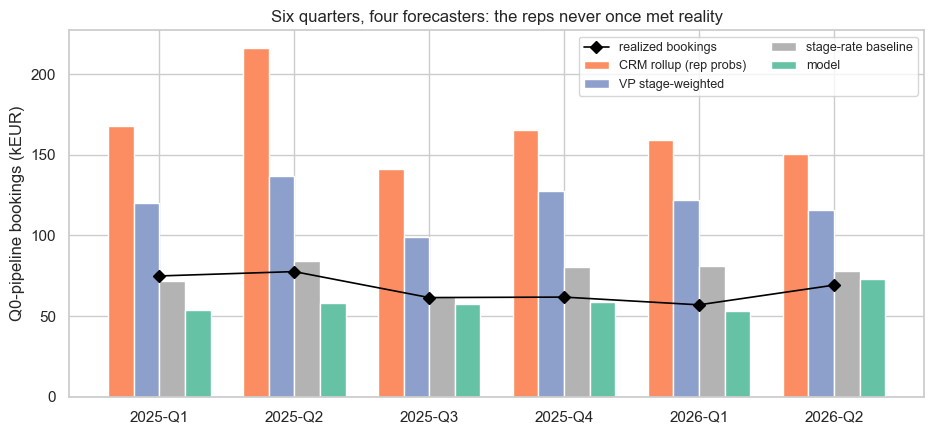

In [13]:
quarters = pd.date_range("2025-01-01", "2026-04-01", freq="QS")
rows, bt_detail = [], {}
for T in quarters:
    fc, realized, pipe_T, pm_T, gi_T, _ = forecast_quarter(T)
    bt_detail[T] = (pipe_T, pm_T, gi_T, realized)          # kept for Stretch C
    rows.append({"quarter": f"{T.year}-Q{T.quarter}", **{k: v / 1e3 for k, v in fc.items()},
                 "realized": realized / 1e3})
bt = pd.DataFrame(rows).set_index("quarter")
print("walk-forward backtest, forecast at week 0 of each quarter (kEUR):")
print(bt.round(0).to_string())

mape = (bt.drop(columns="realized").sub(bt.realized, axis=0).abs()
          .div(bt.realized, axis=0)).mean().sort_values() * 100
print("\nMAPE over the six quarters (%):")
print(mape.round(1).to_string())

METHOD_COLORS = {"CRM rollup (rep probs)": "#fc8d62", "VP stage-weighted": "#8da0cb",
                 "stage-rate baseline": "#b3b3b3", "model": "#66c2a5"}
fig, ax = plt.subplots(figsize=(9.5, 4.5))
x = np.arange(len(bt))
for i, (col, c) in enumerate(METHOD_COLORS.items()):
    ax.bar(x + (i - 1.5) * 0.19, bt[col], 0.19, label=col, color=c)
ax.plot(x, bt.realized, "D-", color="black", ms=6, lw=1.2, label="realized bookings")
ax.set_xticks(x, bt.index)
ax.set_ylabel("Q0-pipeline bookings (kEUR)")
ax.set_title("Six quarters, four forecasters: the reps never once met reality")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()

The backtest is the argument the VP can take upstairs:

- **CRM rollup: 149 % MAPE.** Wrong by ~2.5× *every quarter, in the same direction*. A bias that stable is almost a feature — divide by 2.5 and it would be usable, which is of course exactly what stage-rate baselining implicitly does.
- **VP spreadsheet: 81 %.** Her instinct (down-weight the reps) is right, her constants are folklore.
- **Stage rates: 16.6 %. Model: 12.6 %.** The dumb baseline is *almost* enough — the model's edge comes from knowing that this quarter's pipeline mix (sizes, fit, velocity) differs from the average quarter's. That 4-point margin is the honest size of "ML" in this story, and quoting it honestly is what makes the rest of the memo believable.

Why doesn't the model reach ~0 %? Because a quarter's outcome here hangs on **roughly a dozen wins**: with `n` that small, a perfectly calibrated forecaster still misses by double digits — the miss is *variance, not bias*. Which is exactly why a point forecast is the wrong deliverable. Boards should be handed a **distribution** — and the pipeline's expected value is beautifully easy to simulate: draw each deal as a Bernoulli coin, sum the amounts, repeat.

independent: P10   43k   P50   63k   P90   87k
correlated : P10   37k   P50   64k   P90   97k

THE MEMO NUMBER: Q3-2026 bookings from today's pipeline: EUR 64k (P10-P90: 37-97k)
                 the CRM rollup on the same deals says:   EUR 184k
P(quarter >= CRM's number): 0.0%


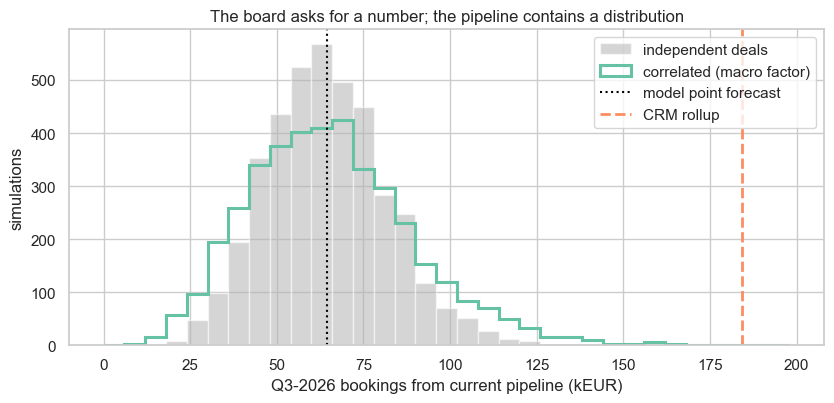

In [14]:
rng_mc = np.random.default_rng(11)
p_eff = np.clip(p_now * g_now, 0.005, 0.98)        # P(books INSIDE the quarter)
amt = pipe_now.amount.to_numpy()

# world 1: deals are independent coins
sims_ind = ((rng_mc.random((4000, len(pipe_now))) < p_eff) * amt).sum(axis=1)
# world 2: a shared macro factor moves every deal's odds together (budget freezes, a great quarter...)
z_macro = rng_mc.normal(0, 0.35, 4000)
p_corr = sigmoid(logit(p_eff)[None, :] + z_macro[:, None])
sims_cor = ((rng_mc.random((4000, len(pipe_now))) < p_corr) * amt).sum(axis=1)

for lbl, s in [("independent", sims_ind), ("correlated ", sims_cor)]:
    q = np.percentile(s, [10, 50, 90]) / 1e3
    print(f"{lbl}: P10 {q[0]:>4.0f}k   P50 {q[1]:>4.0f}k   P90 {q[2]:>4.0f}k")

lo, hi = np.percentile(sims_cor, [10, 90]) / 1e3
print(f"\nTHE MEMO NUMBER: Q3-2026 bookings from today's pipeline: "
      f"EUR {fc_now['model']/1e3:.0f}k (P10-P90: {lo:.0f}-{hi:.0f}k)")
print(f"                 the CRM rollup on the same deals says:   EUR "
      f"{fc_now['CRM rollup (rep probs)']/1e3:.0f}k")
print(f"P(quarter >= CRM's number): {(sims_cor >= fc_now['CRM rollup (rep probs)']).mean():.1%}")

fig, ax = plt.subplots(figsize=(8.5, 4.2))
bins_ = np.arange(0, sims_cor.max() / 1e3 + 8, 6)
ax.hist(sims_ind / 1e3, bins=bins_, color="#b3b3b3", alpha=0.55, label="independent deals")
ax.hist(sims_cor / 1e3, bins=bins_, histtype="step", lw=2.2, color="#66c2a5",
        label="correlated (macro factor)")
ax.axvline(fc_now["model"] / 1e3, color="black", ls=":", lw=1.5, label="model point forecast")
ax.axvline(fc_now["CRM rollup (rep probs)"] / 1e3, color="#fc8d62", ls="--", lw=2, label="CRM rollup")
ax.set_xlabel("Q3-2026 bookings from current pipeline (kEUR)")
ax.set_ylabel("simulations")
ax.set_title("The board asks for a number; the pipeline contains a distribution")
ax.legend()
plt.tight_layout()

Read the histogram before the numbers: the CRM's €184k line sits so far in the right tail that **not one simulation in a thousand reaches it**. The honest statement for the board is *"€64k, with an 80 %-range of roughly €37–97k"* — and the band matters as much as the point.

Two honesty notes, both cheap to say and expensive to skip:

- **Deals are not independent coins.** A budget freeze, a macro wobble, a competitor's price cut — shocks hit the whole pipeline at once. Our shared macro factor widens P10–P90 from €43–87k to **€37–97k**. The widening is the honest part: independence is the assumption that makes forecast bands flattering, and it is always the wrong direction to err.
- **This forecasts *today's pipeline* only.** Deals created *and* closed inside Q3 are invisible this morning; real forecasts add a creation run-rate term for them (all four methods above omit it equally, so the comparison stands — but the absolute number given to the board needs that term too; §6).

What decision hangs on it? Quota and coverage: at the CRM's €184k the VP would request two more reps' worth of Q4 quota; at €64k ± the honest answer is *hold hiring, fix conversion* — specifically the queue in §5, where the same euros are bought far more cheaply.

---

### ✋ Quick exercise (~2 min) — the rollup, by hand

A mini-pipeline, timing factor $g=1$ for all four deals:

| deal | amount | rep prob | model prob |
|---|---|---|---|
| a | €60k | 0.60 | 0.35 |
| b | €25k | 0.80 | 0.70 |
| c | €90k | 0.40 | 0.12 |
| d | €30k | 0.50 | 0.55 |

Compute the CRM rollup and the model forecast. Where does the € gap concentrate — and what is it about deal **c** that makes it the whole story?

In [15]:
# ✍️ Your turn 👇
amounts = np.array([60, 25, 90, 30])   # kEUR
rep_p   = np.array([0.60, 0.80, 0.40, 0.50])
model_p = np.array([0.35, 0.70, 0.12, 0.55])
# rollup = (amounts * rep_p).sum() ...

<details>
<summary>✅ <b>Solution</b></summary>

```python
rollup = (amounts * rep_p).sum()
model_fc = (amounts * model_p).sum()
per_deal = (rep_p - model_p) * amounts
print(f"CRM rollup EUR {rollup:.1f}k, model EUR {model_fc:.1f}k, gap EUR {rollup - model_fc:.1f}k")
for nm, g_ in zip("abcd", per_deal):
    print(f"  deal {nm}: {g_:+.1f}k of the gap")
```

Rollup €107k vs model €65.8k — and **€25.2k of the €41.2k gap is deal c**: a big amount times a modest-looking 28-point probability disagreement. That asymmetry is general and worth internalizing: *forecast gaps live where probability error meets deal size.* It is why Practice 2 builds the "biggest disagreements" list for the Monday pipeline review, and why the VP's gut instinct to argue about the five biggest deals (§6) is not stupid — it is unpriced variance reduction.
</details>

## 5. The lead queue — scoring what to call first

Upstream of every deal is the Monday queue: **~300 new leads, capacity for 120**. Historically HelpDeskAI worked them **first-come-first-served** — whoever called in earliest got called back first. We can do better, but "better" needs a definition, and *conversion probability is the wrong one*. A lead's value is what it eventually books:

$$\text{EV(lead)} = P(\text{convert}) \times \widehat{\text{deal size}} \times P(\text{win} \mid \text{new opportunity})$$

The three factors pull in different directions by design: **big companies convert worse but are worth far more**. So we train two small models on the *worked* leads of the first 110 weeks — conversion (classifier) and deal size (regressor) — and blend with the historical opportunity win rate. One stroke of accidental luck to bank now: FCFS is a terrible *policy* but a great *sampling design* — arrival order is independent of lead quality, so the historical worked set is effectively a random sample and our training data is unbiased. Enjoy it; the moment the score goes live, it dies (end of this section).

In [16]:
lead_tr = leads[(leads.week < 110) & leads.worked]           # history: worked leads have outcomes
lead_te = leads[leads.week >= 110].copy()                     # the last ~5 months: our test weeks

def lead_feats(d):
    return pd.DataFrame({"src": d.source.map({"outbound": 0, "inbound": 1, "partner": 2}),
                         "fit": d.fit_score, "log_emp": np.log10(d.employees)})

conv_model = HistGradientBoostingClassifier(random_state=0, max_leaf_nodes=15,
                                            min_samples_leaf=60).fit(lead_feats(lead_tr), lead_tr.y_conv)
size_model = HistGradientBoostingRegressor(random_state=0, max_leaf_nodes=15, min_samples_leaf=40).fit(
    lead_feats(lead_tr[lead_tr.y_conv]), lead_tr.loc[lead_tr.y_conv, "acv_list"])

train_opps = opps[(opps.opp_created < START + pd.Timedelta(weeks=110)) & opps.resolved]
WIN0 = float(train_opps.won.mean())                           # P(win | new opportunity), history
print(f"P(win | new opportunity), from history: {WIN0:.3f}")

lead_te["p_hat"] = conv_model.predict_proba(lead_feats(lead_te))[:, 1]
lead_te["size_hat"] = size_model.predict(lead_feats(lead_te)).clip(1000, None)
lead_te["ev"] = lead_te.p_hat * lead_te.size_hat * WIN0

wk = lead_te[lead_te.week == 115]
top_conv = set(wk.nlargest(WEEKLY_CAPACITY, "p_hat").index)
top_ev = set(wk.nlargest(WEEKLY_CAPACITY, "ev").index)
print(f"week 115: top-120 by P(convert) vs top-120 by EV share {len(top_conv & top_ev)} leads "
      f"-- {WEEKLY_CAPACITY - len(top_conv & top_ev)} phone calls change")
cols = ["source", "employees", "fit_score", "p_hat", "size_hat", "ev"]
print("\nhighest EV this week:");        print(wk.nlargest(3, "ev")[cols].round(2).to_string(index=False))
print("\nhighest P(convert) this week:"); print(wk.nlargest(3, "p_hat")[cols].round(2).to_string(index=False))

P(win | new opportunity), from history: 0.081
week 115: top-120 by P(convert) vs top-120 by EV share 89 leads -- 31 phone calls change

highest EV this week:
 source  employees  fit_score  p_hat  size_hat     ev
partner      220.0       65.0   0.21  52764.90 883.29
inbound      183.0       69.0   0.21  30814.67 523.18
inbound      175.0       80.0   0.21  29541.56 496.53

highest P(convert) this week:
 source  employees  fit_score  p_hat  size_hat     ev
partner       20.0       92.0   0.58   6175.04 287.33
inbound        3.0       87.0   0.57   4474.89 207.76
inbound        3.0       87.0   0.57   4474.89 207.76


The two rankings visibly disagree — about **a quarter of the queue** swaps out when you rank by euros instead of by conversion probability. The tables show why: the EV list surfaces mid-fit *large* companies (lower `p_hat`, `size_hat` in the tens of thousands), while the conversion list is topped by eager small partner referrals whose deals are a tenth the size. Neither list is "wrong" — they answer different questions, and only one of them is denominated in money.

Does it pay? Same test as always: run the policies against the last 20 weeks. Because we planted the truth, we know `y_conv` for **every** lead — including the ones no SDR ever called. That is god mode (A4's trick): production analytics only observes worked leads, which is precisely why the random holdout at the end of this section is non-negotiable.

policy                        pipeline/week  per SDR-week  precision@120
EV-ranked (ours)                    320.1k        80.0k          0.256
P(convert)-ranked                   267.6k        66.9k          0.270
first-come-first-served             166.4k        41.6k          0.149
biggest companies first             247.4k        61.9k          0.120

a lead pays for its EUR 99 of SDR time iff  p_hat x size_hat > EUR 1,532
break-even queue depth: mean 103 leads/week (min 82, max 121); below capacity (120) in 90% of weeks
marginal lead at rank 120 yields EUR 88 expected margin vs EUR 99 cost


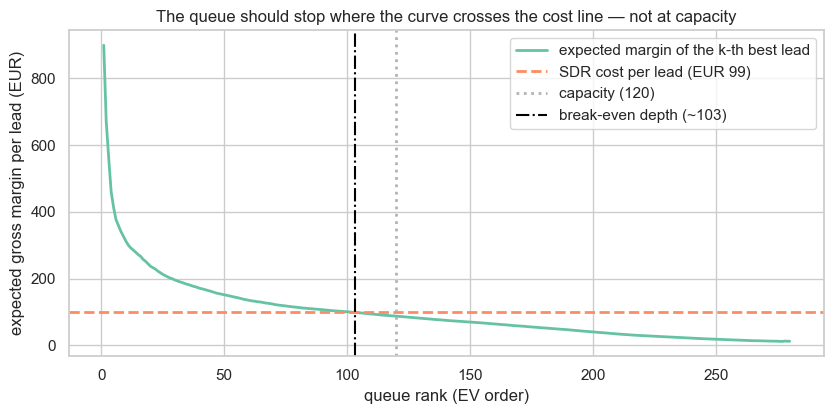

In [17]:
def run_policy(d, col=None, fcfs=False, k=WEEKLY_CAPACITY):
    '''EUR of pipeline created (converted x list ACV) and precision@k, averaged over weeks.'''
    vals, precs = [], []
    for _, g in d.groupby("week"):
        pick = g.sort_values("arrival").head(k) if fcfs else g.sort_values(col, ascending=False).head(k)
        vals.append((pick.y_conv * pick.acv_list).sum())
        precs.append(pick.y_conv.mean())
    return np.mean(vals), np.mean(precs)

print(f"{'policy':<28} {'pipeline/week':>14} {'per SDR-week':>13} {'precision@120':>14}")
for name, kw in [("EV-ranked (ours)", dict(col="ev")), ("P(convert)-ranked", dict(col="p_hat")),
                 ("first-come-first-served", dict(fcfs=True)), ("biggest companies first", dict(col="employees"))]:
    v, pr = run_policy(lead_te, **kw)
    print(f"{name:<28} {v/1e3:>12.1f}k {v/N_SDRS/1e3:>11.1f}k {pr:>14.3f}")

# ---- the break-even: where should the queue STOP? ----
be_threshold = COST_PER_LEAD / (WIN0 * GROSS_MARGIN)
lead_te["marginal_value"] = lead_te.p_hat * lead_te.size_hat * WIN0 * GROSS_MARGIN
depths = lead_te.assign(pays=lead_te.p_hat * lead_te.size_hat > be_threshold) \
                .groupby("week")["pays"].sum().astype(int)
print(f"\na lead pays for its EUR {COST_PER_LEAD:.0f} of SDR time iff  p_hat x size_hat > EUR {be_threshold:,.0f}")
print(f"break-even queue depth: mean {depths.mean():.0f} leads/week (min {depths.min()}, max {depths.max()}); "
      f"below capacity ({WEEKLY_CAPACITY}) in {(depths < WEEKLY_CAPACITY).mean():.0%} of weeks")

# marginal value by queue rank, averaged over the test weeks
ranked = [g.sort_values("ev", ascending=False).marginal_value.to_numpy()[:280]
          for _, g in lead_te.groupby("week")]
avg_marginal = pd.DataFrame(ranked).mean()
mv120 = avg_marginal[119]
print(f"marginal lead at rank 120 yields EUR {mv120:.0f} expected margin vs EUR {COST_PER_LEAD:.0f} cost")

fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(np.arange(1, len(avg_marginal) + 1), avg_marginal, color="#66c2a5", lw=2,
        label="expected margin of the k-th best lead")
ax.axhline(COST_PER_LEAD, color="#fc8d62", ls="--", lw=2, label=f"SDR cost per lead (EUR {COST_PER_LEAD:.0f})")
ax.axvline(WEEKLY_CAPACITY, color="#b3b3b3", ls=":", lw=2, label=f"capacity ({WEEKLY_CAPACITY})")
ax.axvline(depths.mean(), color="black", ls="-.", lw=1.5, label=f"break-even depth (~{depths.mean():.0f})")
ax.set_xlabel("queue rank (EV order)")
ax.set_ylabel("expected gross margin per lead (EUR)")
ax.set_title("The queue should stop where the curve crosses the cost line — not at capacity")
ax.legend()
plt.tight_layout()

Three money sentences for the ops review:

- **EV-ranking nearly doubles FCFS**: €80.0k vs €41.6k of expected pipeline per SDR-week — same people, same phones, different sort order. It also beats conversion-ranking (€66.9k) despite a *lower* precision@120 (0.256 vs 0.270): it deliberately spends calls on harder, bigger leads. Precision is a proxy; euros are the objective. And "call the biggest companies" (€61.9k, precision 0.120) fails in the instructive direction — size without conversion probability burns the queue on unconvertible whales.
- **The queue should stop at ~103, not 120.** The marginal 120th lead returns ~€88 of expected margin against €99 of SDR cost. In 90 % of weeks the economic queue is *shorter than capacity* — the leftover hours belong in follow-ups or partner sourcing, not in dialing outbound leads that cost more than they yield. Capacity is a constraint, not a target.
- **The score will poison its own successor.** Next quarter's worked leads are the ones *this model chose* — conversion labels will exist only for high-scoring leads, and retraining on them inherits the bias (A4's §1 in sales clothing; A3 §6's selective labels, upstream edition). The fix costs one sentence in the ops plan: **a 10 % random slice of the queue is worked regardless of score** (A2's discipline). That slice is the only part of next quarter's data you'll be able to trust.

---

### ✋ Quick exercise (~2 min) — when to stop calling

It is week 129 — the freshest week in the data. Using `lead_te`: **(a)** recompute the break-even threshold from `COST_PER_LEAD`, `WIN0` and `GROSS_MARGIN`; **(b)** count how many of this week's leads clear it; **(c)** the SDRs have capacity for 120 — how many calls should they *actually* make, and what should they do with the rest of the time?

In [18]:
# ✍️ Your turn 👇
wk129 = lead_te[lead_te.week == 129]
# threshold = COST_PER_LEAD / (WIN0 * GROSS_MARGIN)
# n_worth = (wk129.p_hat * wk129.size_hat > threshold).sum()

<details>
<summary>✅ <b>Solution</b></summary>

```python
threshold = COST_PER_LEAD / (WIN0 * GROSS_MARGIN)
n_worth = int((wk129.p_hat * wk129.size_hat > threshold).sum())
print(f"threshold: p x size > EUR {threshold:,.0f}")
print(f"week 129: {len(wk129)} leads arrived, {n_worth} clear break-even, capacity {WEEKLY_CAPACITY}")
print(f"-> make {min(n_worth, WEEKLY_CAPACITY)} calls, hold back "
      f"{max(WEEKLY_CAPACITY - n_worth, 0)} lead-slots of SDR time")
```

The threshold algebra: a worked lead is worth `p_conv × size × WIN0 × margin`; setting that against €99 of SDR time gives `p × size > 99 / (0.081 × 0.8) ≈ €1,532`. This week 106 of 307 leads clear it — so the right plan is **106 calls, not 120**, with the spare 14 lead-slots of SDR time going to follow-up touches on open opportunities (whose marginal value §4 just quantified). One refinement before you promote the rule: keep the 10 % random slice *below* the threshold too — the whole point is to keep observing the leads the model says aren't worth observing.
</details>

## 6. What real revenue-ops teams add (honest section)

Everything above is the load-bearing 80 %. What production revenue operations layers on top:

- **Goodhart, everywhere.** The moment stage-conversion or velocity feeds a forecast (or a bonus), reps learn to game it — stages advanced early to look fast, deals parked in "Qualified" to sandbag the commit. Real teams pin stage definitions to *verifiable exit criteria* (demo happened, proposal sent), audit stage regressions, and re-check the reliability curve every quarter, because calibration is a moving target when the measured know they're measured (Stretch D simulates exactly this).
- **New-pipeline creation.** We forecast the deals that exist. A real quarter also books deals created *inside* it, so production forecasts add a creation-and-fast-close run-rate term with its own error band — and pipeline-*generation* forecasting is its own discipline.
- **Commit rituals.** "Commit / best case / pipeline" categories are a human quantile forecast — a P90/P50/P10 in sales vocabulary. The mature version reconciles them against the Monte-Carlo quantiles instead of replacing them: when a rep's commit and the model's P90 disagree, *that conversation* is where forecast accuracy actually improves.
- **Deal desk & the five whales.** Our model treats a €140k Enterprise deal as one more Bernoulli coin. Real orgs put humans on it: legal review, discount approvals, an executive sponsor — and the VP's gut on the five biggest deals genuinely matters, because *n = 5 is not a modeling problem*. The model's job is the other 70 deals, so the humans can afford to obsess over five.
- **Seasonality & fiscal calendars.** Enterprise buying bunches at quarter-ends (yours *and the customer's*) and dies in August. Our simulator has no seasons; production timing factors are estimated per fiscal week, not as one flat `g(stage)`.
- **Multi-touch attribution wars.** We credited each lead to one source. Real leads see an ad, a webinar and a partner intro; splitting that credit (first-touch? last-touch? Shapley?) is a swamp with a budget attached — which is why A2-style *experiments on channel spend* beat attribution archaeology whenever you can afford them.
- **CRM hygiene as a product.** The stage log we relied on exists only if someone made the CRM record field history and made reps' lives easier when they keep it accurate. The unglamorous truth: half of "sales AI" is data contracts for the sales team.

## 🧠 The story in one screen

| # | The move | The number that carries it |
|---|---|---|
| 1 | ~30 months of CRM: leads → opportunities → staged deals | 2,466 opps, win 8.1 %; funnel ≈ 8/17/35/57/72 % |
| 2 | Train on the current export (post-close edits) | **AUC 1.000** — `last_stage_reached` alone: 0.990 |
| 2 | Rebuild features as-of biweekly snapshots, censor open deals | honest AUC **0.853** |
| 3 | Reliability curve of rep-entered probabilities | "20 %" wins **9.9 %**; "80 %" wins **55.6 %** |
| 3 | Per-rep calibration personas | happy ears −33.9 pp; sandbaggers ≈ 0 |
| 3 | Stage-rate baseline vs reps vs model (Brier) | 0.111 vs 0.175 vs **0.108** — the win is calibration |
| 4 | Q3 forecast three ways | CRM **€184k** vs VP €137k vs model **€64k** (2.9×) |
| 4 | Walk-forward backtest, 6 quarters (MAPE) | model **12.6 %** < stage 16.6 < VP 80.8 < CRM 149.2 |
| 4 | Monte-Carlo band; correlation widens it | P10–P90 €43–87k → **€37–97k**; P(≥ CRM) ≈ 0 % |
| 5 | EV-ranked queue vs FCFS, per SDR-week | **€80.0k vs €41.6k** (conv-ranked €66.9k) |
| 5 | Break-even queue depth vs capacity | stop at **~103** of 120; rank-120 lead: €88 < €99 cost |
| 5 | Tomorrow's training data | 10 % random slice, or A4's selection bias eats the retrain |

## 🧪 Practice exercises

### Exercise 1 — ⭐ The VP's spreadsheet, audited

The VP's weights (10/25/45/60/85) were folklore. Audit them properly: build a per-stage table comparing her weights with the training panel's empirical rates (`stage_rates`), compute her Brier score on the honest test panel `pte` alongside the baseline's, and price the folklore — how many euros of the current-quarter forecast gap (`fc_now`) between her number and the stage-rate baseline's does each stage contribute?

In [19]:
# Starter
# vp_p = VP_W[pte.stage_idx.to_numpy()] ... brier_score_loss(pte.won, vp_p)
# per-stage EUR: group pipe_now by stage; gap_per_stage = (VP_W - stage_rates) * g * amount

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
audit = pd.DataFrame({"VP weight": VP_W,
                      "empirical rate": stage_rates.reindex(range(5)).round(3).to_numpy()},
                     index=STAGES)
audit["gap_pp"] = ((audit["VP weight"] - audit["empirical rate"]) * 100).round(1)
print(audit.to_string())

vp_p = VP_W[pte.stage_idx.to_numpy()]
sr_p = pte.stage_idx.map(stage_rates).to_numpy()
print(f"\nBrier: VP {brier_score_loss(pte.won, vp_p):.4f} vs stage rates "
      f"{brier_score_loss(pte.won, sr_p):.4f} vs reps {brier_score_loss(pte.won, pte.rep_prob):.4f}")

per_stage = pipe_now.assign(gap=(VP_W[pipe_now.stage_idx.to_numpy()]
                                 - pipe_now.stage_idx.map(stage_rates).to_numpy())
                                * g_now * pipe_now.amount).groupby("stage").gap.sum()
print(f"\nEUR of VP-vs-baseline forecast gap by stage (total {per_stage.sum()/1e3:.0f}k):")
print((per_stage.reindex(STAGES) / 1e3).round(1).to_string())
```

Her weights overstate every stage — by 3 pp at Lead up to 24 pp at Negotiation — but the *euros* concentrate where the deals are: Qualified and Demo alone carry ~€30k of the ~€48k gap. (The printed 48k vs `fc_now`'s 47k is baseline vintage: this `stage_rates` was fitted as of 1 January, `fc_now`'s as of 29 June.) The fix costs one `groupby`. The interesting sociological question — why a VP who *knows* the reps are optimistic still lands optimistic herself — has a §6 answer: her constants came from remembered win rates of *deals that made it far enough to be memorable*. Availability bias is selection bias with better anecdotes.
</details>

### Exercise 2 — ⭐⭐ The Monday disagreement list

The sales manager can review five deals in Monday's pipeline meeting. Build the list that spends those five slots best: for the current pipeline (`pipe_now`, model probs `p_now`), rank open deals by the **euro-weighted disagreement** `(rep_prob − model_p) × amount` and print the top 5 in each direction (rep ≫ model, and model ≫ rep). What should the meeting *do* with each half of the list?

In [20]:
# Starter
# review = pipe_now.assign(p_model=p_now, gap_eur=(pipe_now.rep_prob - p_now) * pipe_now.amount)
# .nlargest(5, "gap_eur") / .nsmallest(5, "gap_eur")

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
review = pipe_now.assign(p_model=np.round(p_now, 2),
                         gap_eur=((pipe_now.rep_prob - p_now) * pipe_now.amount).round(-2))
cols = ["opp_id", "rep", "stage", "amount", "rep_prob", "p_model", "gap_eur"]
print("rep much more optimistic than model -- CHALLENGE these:")
print(review.nlargest(5, "gap_eur")[cols].to_string(index=False))
print("\nmodel more optimistic than rep -- possible sandbagged upside:")
print(review.nsmallest(5, "gap_eur")[cols].to_string(index=False))
print(f"\ntotal optimism overhang in the pipeline: EUR {review.gap_eur.sum()/1e3:.0f}k")
```

The top half is where the CRM's €120k of Q3 optimism physically lives — big amounts wearing rep probabilities the reliability curve says are fiction; the meeting asks *"what has to be true for your 70 %?"* and either gets evidence or gets the field updated. The bottom half is the sandbagged upside — deals the model likes better than their own rep does; those get resourcing, not interrogation. Note what this list is *not*: a lie detector. Half the top-5 will be reps being honestly wrong, which is precisely why the conversation reviews **deals**, not people.
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: the 0.97-AUC pipeline model

A colleague heard about §2 too late. Their "deal-scoring model for the Monday review" is below — it runs without error, evaluates with a temporal split, and reports a spectacular number (their Slack message: *"even better than the churn model!"*). Find all three leaks, explain why each column cannot exist at scoring time, and fix the pipeline. (You met this exact trap in NB 23's Debug-me — the 0.99-AUC refund flag. Same disease, different host.)

In [21]:
# A colleague's deal scorer -- runs fine, evaluates 'great'. What's wrong?
scored = crm[crm.resolved].copy()
scored["recency"] = (DATA_END - scored.close_date).dt.days          # "freshness of the record"
COLS = ["amount_now", "recency", "days_in_pipeline"]
tr_b = scored[scored.opp_created < "2025-07-01"]
te_b = scored[scored.opp_created >= "2025-07-01"]
buggy = HistGradientBoostingClassifier(random_state=0).fit(tr_b[COLS], tr_b.won)
auc_b = roc_auc_score(te_b.won, buggy.predict_proba(te_b[COLS])[:, 1])
print(f"deal-scoring AUC: {auc_b:.3f}   <- 'even better than the churn model!' 🚩")

deal-scoring AUC: 0.967   <- 'even better than the churn model!' 🚩


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
# All three columns are POST-OUTCOME:
#   amount_now       -- rewritten at close: final ACV if won, zeroed/slashed if lost
#   recency          -- computed FROM close_date, which doesn't exist for the deals you'd score
#   days_in_pipeline -- also computed from close_date for resolved deals
# The tell nobody checked: the model is meant to score OPEN deals -- for which
# recency and days-to-close are undefined. It could literally never run in production.
p_fix = honest.predict_proba(pte[FEATS])[:, 1]      # the §2 rebuild IS the fix
print(f"buggy (current-table fields): AUC {auc_b:.3f}")
print(f"fixed (as-of features)      : AUC {roc_auc_score(pte.won, p_fix):.3f}")
print("NB 26's question closes the case: 'would this value exist in the DB at scoring time?'")
```

The buggy model scores **0.967** and the honest one **0.853** — and the honest one is the *better* model, because 0.967 measures the ability to read edited records of finished deals, a skill worth nothing on Monday morning. Notice the practical tell in the comment above: the buggy features are **undefined for open deals**. A model whose features cannot even be *computed* for its production population is leakage announcing itself — checking that is a one-line code review that would have caught this before the Slack message.
</details>

### Exercise 4 — ⭐⭐ Which lead source pays?

Marketing wants budget reallocated and cites conversion rates. Do the funnel economics properly: for each source, using *worked* leads, compute conversion, average deal size, and **expected gross margin per 100 worked leads** (`conv × WIN0 × avg ACV × margin × 100`). Then two decisions: (a) partner referrals carry a **15 % first-year revenue share** — are they still the best source net of it? (b) Compare outbound's margin per worked lead with `COST_PER_LEAD` — what does that say about the default policy of cold-calling every outbound lead?

In [22]:
# Starter
# econ = leads[leads.worked].groupby("source").agg(conv=("y_conv","mean"), acv=("acv_list","mean"))
# econ["margin_per_100"] = econ.conv * WIN0 * econ.acv * GROSS_MARGIN * 100

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
econ = leads[leads.worked].groupby("source").agg(n=("y_conv", "size"), conv=("y_conv", "mean"),
                                                 acv=("acv_list", "mean"))
econ["margin_per_100"] = (econ.conv * WIN0 * econ.acv * GROSS_MARGIN * 100).round(0)
econ["rev_share_per_100"] = np.where(econ.index == "partner",
                                     (econ.conv * WIN0 * econ.acv * 0.15 * 100).round(0), 0.0)
econ["net_per_100"] = econ.margin_per_100 - econ.rev_share_per_100
print(econ.round(3).to_string())
print(f"\noutbound: EUR {econ.loc['outbound', 'margin_per_100']/100:.0f} of margin per worked lead "
      f"vs EUR {COST_PER_LEAD:.0f} of SDR cost -> underwater on average")
```

Partner referrals survive their 15 % haircut comfortably — roughly €22k gross per 100 worked leads against ~€4k of revenue share — still the best euros in the building; the actionable question becomes *"what does the 101st partner lead cost to generate?"*, which is marketing's side of §5's break-even. The louder result is outbound: **~€33 of expected margin per worked lead against €99 of SDR cost**. Cold-calling outbound *by default* loses money three-to-one; §5's EV ranking already knew this, which is why outbound survives only as the occasional big-company exception. Note what we did *not* conclude: "kill outbound". We concluded *stop working outbound leads below the EV bar* — policies beat prejudices.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Per-rep calibration with shrinkage — fixing people, gently

§3 fixed calibration by ignoring the reps. Try fixing the reps instead: estimate each rep's personal log-odds offset $\delta_r = \overline{\text{logit}(p_{\text{rep}})} - \text{logit}(\bar y_r)$ on **training-panel rows** (`ptr`), then shrink it toward the global offset with an empirical-Bayes weight $w_r = n_r / (n_r + K)$, $K \approx 150$ (small-*n* reps get mostly the global fix). Apply the corrected probabilities to the test panel `pte` and compare Brier: raw reps → global offset only → per-rep shrunk. Does personalizing beat the one-size-fits-all fix, and by how much relative to the stage-rate baseline?

In [23]:
# Starter -- sketch:
# glob = ptr.rep_prob (logit mean) - logit(ptr.won.mean())
# per rep r: delta_r on ptr rows; w_r = n/(n+150); delta_shrunk = w*delta_r + (1-w)*glob
# corrected pte prob = sigmoid(logit(rep_prob) - delta_shrunk[rep]); Brier-compare

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def smooth_rate(y):                                  # Laplace-smoothed win rate, keeps logit finite
    return (y.sum() + 1) / (len(y) + 2)

lg_tr = logit(ptr.rep_prob.clip(0.05, 0.95))
glob = lg_tr.mean() - logit(smooth_rate(ptr.won))
K = 150
delta = {}
for r, g_r in ptr.groupby("rep"):
    d_r = logit(g_r.rep_prob.clip(0.05, 0.95)).mean() - logit(smooth_rate(g_r.won))
    w = len(g_r) / (len(g_r) + K)
    delta[r] = w * d_r + (1 - w) * glob

lg_te = logit(pte.rep_prob.clip(0.05, 0.95))
p_glob = sigmoid(lg_te - glob)
p_shrunk = sigmoid(lg_te - pte.rep.map(delta))
for nm, p in [("raw reps", pte.rep_prob), ("global offset", p_glob), ("per-rep shrunk", p_shrunk),
              ("stage rates", pte.stage_idx.map(stage_rates))]:
    print(f"{nm:>15}: Brier {brier_score_loss(pte.won, p):.4f}  mean {np.mean(p):.3f}")
```

The global offset alone removes most of the damage (it *is* the level fix, learned instead of tabulated), and the per-rep shrunk version adds a further small slice by treating R01's numbers differently from R03's. But note where the corrected reps land: **still behind the stage-rate baseline** — because after you subtract each rep's personality, what remains of their number is mostly… the stage, observed with noise. The hierarchy (rep → team → global) is the same shrinkage pattern you'd apply to any small-*n* group estimate — worth having in your hands well beyond sales. And operationally, $\delta_r$ has a second life: it is a *coaching number* ("your 60 % runs 22 points hot") that survives roster churn via the prior.
</details>

### Stretch exercise B — ⭐⭐⭐ The survival view — when is a deal stale?

§3 noted that snapshot win rates sit below at-entry win rates because lingering deals are worse. Make that precise: for Demo and Proposal, compute $P(\text{win} \mid \text{still in the stage after } d \text{ days})$ on resolved deals for $d \in \{0, 10, 20, 30, 45, 60\}$ (a deal is "still in the stage after $d$ days" if its time-in-stage exceeded $d$). Plot the two decay curves. Then define a **staleness rule** — the day $d^\*$ where the conditional win rate falls below half its $d=0$ value — and price the current pipeline's stale deals: how much CRM-rollup value (`rep_prob × amount`) is sitting on deals past their $d^\*$?

In [24]:
# Starter -- sketch:
# res_log = stage_log + won/close merge; time_in_stage = next entered (or close) - entered
# for d in grid: cond = time_in_stage >= d; win rate among cond
# stale EUR: pipe_now[pipe_now.days_in_stage > d_star] -> (rep_prob * amount).sum()

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
res_log = stage_log.merge(opps[["opp_id", "won", "resolved", "close_date"]], on="opp_id")
res_log = res_log[res_log.resolved].sort_values(["opp_id", "entered"])
res_log["left"] = res_log.groupby("opp_id").entered.shift(-1).fillna(res_log.close_date)
res_log["t_in_stage"] = (res_log.left - res_log.entered).dt.days

grid = [0, 10, 20, 30, 45, 60]
fig_s, ax_s = plt.subplots(figsize=(7.5, 4))
d_star = {}
for stage_nm, c in [("Demo", "#66c2a5"), ("Proposal", "#8da0cb")]:
    sub = res_log[res_log.stage == stage_nm]
    curve = [sub.loc[sub.t_in_stage >= d, "won"].mean() for d in grid]
    ax_s.plot(grid, np.array(curve) * 100, "-o", color=c, label=stage_nm)
    d_star[stage_nm] = next((d for d, v in zip(grid, curve) if v < curve[0] / 2), 60)
ax_s.set_xlabel("days already spent in stage"); ax_s.set_ylabel("P(win | still there) (%)")
ax_s.set_title("Deals age like fish, not wine"); ax_s.legend(); plt.tight_layout()
print("staleness thresholds d*:", d_star)

stale = pipe_now[pipe_now.apply(lambda r: r.days_in_stage > d_star.get(r.stage, 60), axis=1)]
print(f"stale deals in the current pipeline: {len(stale)} of {len(pipe_now)}; "
      f"CRM value parked on them: EUR {(stale.rep_prob * stale.amount).sum()/1e3:.0f}k")
```

Both curves halve by day ~45 — the fast-mover effect §1 planted, read from the other end: *time in stage is negative information*, and the model has been quietly using it via `days_in_stage` all along. The staleness rule turns it into pipeline hygiene the CRM can enforce ("Demo/Proposal deals untouched for 45 days get re-qualified or closed-lost"). Today's catch is small — 2 deals, ~€7k of parked rollup value — because this pipeline happens to be young; the rule earns its keep at quarter-end, when stale deals pile up precisely where the commit pressure is. This is survival analysis by fingers; `lifelines` gives you the same curves with censoring handled properly, which matters once you include the *open* deals we had to exclude here.
</details>

### Stretch exercise C — ⭐⭐⭐ Forecast the quarter in quantiles, then check your coverage

A P10–P90 band is a *promise*: the realized number should land inside it ~80 % of the time. Audit our own promise: for each of the six backtest quarters (`bt_detail` holds each quarter's pipeline, model probabilities, timing factors, and realized bookings), run the Monte-Carlo — both independent and correlated variants — and count how often realized bookings fell inside each P10–P90. With six quarters you cannot *prove* calibration (the binomial noise on 6 trials is huge — say so), but you can catch gross overconfidence. Which variant keeps its promise better?

In [25]:
# Starter -- sketch:
# for T, (pipe_T, pm_T, gi_T, realized) in bt_detail.items():
#     p_eff = clip(pm_T * gi_T, ...); sims indep + correlated (own default_rng per quarter)
#     inside = P10 <= realized <= P90

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
hits = {"independent": 0, "correlated": 0}
rng_q = np.random.default_rng(21)
print(f"{'quarter':<9} {'realized':>9} {'indep P10-P90':>16} {'corr P10-P90':>15}  in band?")
for T, (pipe_T, pm_T, gi_T, realized) in bt_detail.items():
    p_e = np.clip(pm_T * gi_T, 0.005, 0.98)
    a = pipe_T.amount.to_numpy()
    s_i = ((rng_q.random((2000, len(pipe_T))) < p_e) * a).sum(axis=1)
    zq = rng_q.normal(0, 0.35, 2000)
    s_c = ((rng_q.random((2000, len(pipe_T))) < sigmoid(logit(p_e)[None, :] + zq[:, None])) * a).sum(axis=1)
    li, hi_i = np.percentile(s_i, [10, 90]); lc, hc = np.percentile(s_c, [10, 90])
    hits["independent"] += li <= realized <= hi_i
    hits["correlated"] += lc <= realized <= hc
    print(f"{T.year}-Q{T.quarter:<4} {realized/1e3:>8.0f}k {li/1e3:>7.0f}-{hi_i/1e3:.0f}k "
          f"{lc/1e3:>8.0f}-{hc/1e3:.0f}k   {'✅' if lc <= realized <= hc else '❌'}")
print(f"\ncoverage (target ~80%): independent {hits['independent']}/6, correlated {hits['correlated']}/6")
```

The correlated bands, being wider, cover at least as many quarters — and typically the independent bands miss one that the correlated ones catch, which is the whole argument for the macro factor made empirical. The honest caveat belongs in the printout: with 6 trials, 4/6 and 6/6 are both consistent with true 80 % coverage (the 95 % binomial range spans ~3–6), so what this audit can actually detect is *gross* overconfidence — bands that miss half the time. That is not a weakness of the method; it is the sample size of quarters, and it is why real forecast teams also backtest at monthly grain, where n grows faster than politics.
</details>

### Stretch exercise D — ⭐⭐⭐ Simulate the Goodhart effect — the reps learn your features

Quarter two of the model's life: word gets out that "deals that move fast score high". Reps start advancing deals to the next stage early — nothing about the customers changes, only the CRM's *story* about them. Simulate it on a copy of the current pipeline: bump every deal one stage forward (cap at Negotiation), cut `days_in_stage` to at most 5, recompute `velocity` accordingly, and re-score with `model_now`. How much does the Q3 forecast inflate while reality moves €0? Then propose two defenses (think: which features can a rep *not* unilaterally edit, and which §3 artifact would catch the drift within a quarter?).

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
gamed = pipe_now.copy()
gamed["stage_idx"] = np.minimum(gamed.stage_idx + 1, 4)
gamed["days_in_stage"] = np.minimum(gamed.days_in_stage, 5)
gamed["velocity"] = gamed.stage_idx / gamed.days_open.clip(lower=1) * 30
p_gamed = model_now.predict_proba(gamed[FEATS])[:, 1]
fc_gamed = float((p_gamed * g_now * gamed.amount).sum())   # same timing factors: only the STORY changed
print(f"honest forecast : EUR {fc_now['model']/1e3:.0f}k")
print(f"gamed forecast  : EUR {fc_gamed/1e3:.0f}k  (+{(fc_gamed/fc_now['model'] - 1) * 100:.0f}% "
      f"from editing fields, EUR 0 from reality)")
```

The forecast jumps **+75 %** — from €64k to €113k — while not one customer changed their mind: Goodhart's law demonstrated in four lines. *when a measure becomes a target, it ceases to be a good measure.* Defenses, in the order real teams deploy them: **(1)** anchor stages to verifiable exit criteria (a demo has a calendar event; a proposal has a document) so advancing a stage requires forgeable-but-auditable evidence; **(2)** privilege features reps cannot unilaterally edit — source, company size, fit score, *customer-side* activity; **(3)** keep §3's reliability curve on a quarterly cron: gamed stages show up as a fresh calibration sag at exactly the gamed stages, usually within one quarter. The uncomfortable equilibrium to accept: any forecast good enough to matter will be gamed a little; the goal is to make gaming *costly and visible*, not impossible.
</details>

## 🎁 Bonus mini-project — the board forecast memo

Write the one-pager the VP should actually take into the board meeting. It must answer, with numbers traceable to cells above, and **naming the probability source behind every euro** (*rep-entered*, *stage-rate*, or *model, as-of features*):

1. **The number.** Q3 bookings from the current pipeline: point forecast + P10–P90 (correlated band), next to the CRM rollup — with one sentence on why the €120k gap exists and whom it should worry.
2. **The track record.** The six-quarter walk-forward table and MAPE ranking — the paragraph that buys the model its credibility, because it shows the method being right *before* this quarter.
3. **The caveats, priced.** Deals-not-yet-created (excluded; add the run-rate separately), the five largest open deals listed by name for human judgment (n = 5 is not a modeling problem), and the correlation assumption behind the band.
4. **The asks.** (a) Replace rep probabilities with model probabilities *in the rollup only* — reps keep entering their numbers (they feed the disagreement list and the calibration table, both of which you should attach as appendix exhibits); (b) EV-ranked lead queue with the ~103-lead stop rule and the **10 % random slice**, priced at what §5 says it is worth per SDR-week; (c) a quarterly re-calibration ritual for the reliability curve (Stretch D's defense).

Grading yourself: every number should be reproducible by re-running one named cell; every probability should name its source; and the memo should survive the hardest board question there is — *"how were you wrong last quarter, and by how much?"* — with a table instead of an anecdote.

## ✅ Self-assessment checklist

- [ ] I can explain **post-outcome leakage** in CRM data without the word "leakage": the export remembers the ending, and models read it backwards.
- [ ] I can rebuild features **as-of a date** from a field-history log, and I know why a deal appears once per snapshot it was open in.
- [ ] I know which deals are **censored** at training time and why "cohorts old enough to have resolved" is the honest training population.
- [ ] I can read a **reliability curve** and price a miscalibrated probability in euros on a real deal.
- [ ] I beat the reps with a `groupby` before I beat the `groupby` with a model — and I can say which part of the model's win was **calibration vs ranking**.
- [ ] My quarter forecast is a **distribution**, its band widens for correlated outcomes, and it has a walk-forward track record, not a vibe.
- [ ] I rank lead queues by **expected value**, stop at the **break-even depth** even with capacity left, and always keep a **random slice** so next quarter's model has honest food.
- [ ] I know the five biggest deals belong to humans, and the reliability curve gets re-checked whenever the measured learn they are being measured.

---

> 🧭  [◀ A6 — Finance: AR & Cash Flow](./A6_finance_ar_cashflow.ipynb)  ·  [Module 7 index](./README.md)  ·  [A8 — Procurement & Spend ▶](./A8_procurement_spend.ipynb)  ·  [🏠 Course home](../README.md)
